# Inicialización

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append('..')  # allow importing from parent directory
from fun_gilles import *
import pickle
import pandas as pd

In [2]:
colors = plt.get_cmap('Set2').colors
plt.rcParams["axes.formatter.use_mathtext"] = True
plt.rcParams["axes.formatter.useoffset"]= False

In [3]:
title_fs = 16
label_fs = 15
tick_fs = 14
legend_fs = 14

In [4]:
f = '../examples/reactions_autocat.txt'
reactions = read_file(f)
species = obtain_species(reactions)

In [5]:
def plot(abundances, times, V, SPECIES):
    colors = plt.get_cmap('Set2').colors
    colors = colors

    fig, axes = plt.subplots(nrows=2, ncols=1, sharex=True, figsize=(7,5)) 

    # --- Subplot 1: Concentration ---
    ax1 = axes[0]
    for i in range(len(SPECIES)):
        # Calculate concentration = Abundance / Volume
        ax1.plot(times, abundances[:, i] / V, label=SPECIES[i], color=colors[i], alpha=0.9, linewidth= 2)
    ax1.grid(True, linestyle='--', alpha=0.3)
    ax1.set_xlabel("Time", fontsize= label_fs)
    ax1.set_ylabel("Concentration", fontsize= label_fs)
    ax1.set_title("Concentration Evolution", fontsize= title_fs)
    ax1.legend(loc='center left', bbox_to_anchor=(1.05, 0.5), title="SPECIES", fontsize= legend_fs)
    ax1.tick_params(axis='both', labelsize=tick_fs)

    # --- Subplot 2: Volume ---
    ax2 = axes[1]
    ax2.plot(times, V, color='gray',alpha=0.9,linewidth= 2)
    ax2.grid(True, linestyle='--', alpha=0.3)
    ax2.set_xlabel("Time", fontsize= label_fs)
    ax2.set_ylabel("Volume", fontsize= label_fs)
    ax2.set_title("Volume Evolution", fontsize= title_fs)
    ax2.tick_params(axis='both', labelsize=tick_fs)
   
    plt.tight_layout(rect=[0, 0, 1, 1]) 
    plt.show()

In [6]:
def load_streamed_pickle(filename):
    data = {}
    try:
        with open(filename, "rb") as file:
            while True:
                try:
                    # Load one object (which is a dict of {k_i: (abundances, times, volumes)})
                    chunk = pickle.load(file)
                    # Merge the loaded chunk into the main dictionary
                    data.update(chunk)
                except EOFError:
                    # Reached the end of the file
                    break
    except FileNotFoundError:
        print(f"Error: File '{filename}' not found.")
    
    print(f"Successfully loaded {len(data)} simulation results.")
    return data

In [7]:
def get_alpha_single_run(cond:float, result:tuple, values_used = None):
    _, times, volumes = result
        
    times = np.array(times)
    volumes = np.array(volumes)
    
    # Use data points from index len/5 onwards
    if values_used == None:
        start_idx = round(len(volumes) / 5)
        log_v = np.log(volumes[start_idx:])
        t_subset = times[start_idx:]
    
    else:
        values_used = round(len(volumes) * values_used)
        log_v = np.log(volumes[:values_used])
        t_subset = times[:values_used]
    
    # Perform linear regression
    # polyfit(x, y, 1) returns [slope, intercept]
    coefficients = np.polyfit(t_subset, log_v, 1)
    m_fit = coefficients[0]      # This is alpha (slope)
    log_A_fit = coefficients[1]  # This is the intercept
    A_fit = np.exp(log_A_fit)
    
    # --- R-SQUARED CALCULATION ---
    log_v_predicted = log_A_fit + m_fit * t_subset
    log_v_mean = np.mean(log_v)
    SS_res = np.sum((log_v - log_v_predicted)**2)
    SS_tot = np.sum((log_v - log_v_mean)**2)
    R_squared = 1 - (SS_res / SS_tot) if SS_tot != 0 else 0
    
    
    rmse = np.sqrt(SS_res / len(volumes)) if len(volumes) > 0 else 0
    
    # Return a dictionary directly
    return {
        'Condition': cond,
        'Alpha': m_fit,
        'Scaling Const. (A)': A_fit,
        'R^2': R_squared,
        'RMSE': rmse
    }

In [8]:
def plot_all_volumes_AB(results: dict, xlim= None, ylim= None, lim= None, rep= 0, fig_name= None):
    if lim != None:
        filtered_conditions = [c for c in results.keys() if float(c) < lim[1]]

        filtered_conditions = [c for c in filtered_conditions if float(c) > lim[0]]

    else:
        filtered_conditions = results
        
    # Update the color gradient length
    color_gradient = plt.cm.rainbow(np.linspace(0, 1, len(filtered_conditions)))
    plt.figure(figsize=(4,3.7))
    # Then loop through filtered_conditions instead of results.items()
    for j, condition in enumerate(filtered_conditions):
        replicates = results[condition]
              
        if not isinstance(replicates, tuple):
            # for rep in replicates:
            if isinstance(replicates[rep], dict):
                data_tuple = list(replicates[rep].values())[0]
            else:
                data_tuple = replicates[rep]
            a, t, v = data_tuple
            # print(fr"For simulation $k_{i}$ = {condition}") 
            # print(fr"-  Highest volume = {max(v)}")
            # print(fr"-  Lowest volume = {min(v)}")
            plt.plot(t, v, color=color_gradient[j], label=condition, alpha = 0.9, linewidth= 2)    

    plt.legend(title = rf"Value of $[AB]_0$", fontsize= legend_fs,
            loc='center left', bbox_to_anchor=(1.05, 0.5), title_fontsize= title_fs)
    if xlim != None:
        plt.xlim((0,xlim))

    if ylim!= None:
        plt.ylim(ylim)
    
    import matplotlib.ticker as ticker
    ax = plt.gca()
    ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=5))
    plt.yscale('log')
    plt.xlabel("Time", fontsize = label_fs)
    plt.ylabel("Volume", fontsize = label_fs)
    plt.axhline(y= v[0]*2, color= 'darkgray', alpha= 0.6, linestyle=":")
    plt.tick_params(axis='both', labelsize= tick_fs)
    if fig_name != None:
        plt.savefig(f"../figures_TFM/{fig_name}.png")
    plt.show()



In [9]:
def identify_reaction_history(abundance_matrix, c_matrix):
    """
    abundance_matrix: (Steps x Species) matrix of counts
    c_matrix: (Reactions x Species) stoichiometry matrix
    """
    # 1. Calculate the change in molecules between each time step
    # diffs will have shape (Steps-1, Species)
    # eliminamos food species: no cambian según la matriz c
    diffs = np.diff(abundance_matrix, axis=0)[:, 4:]
    c_matrix = c_matrix[:, 4:]
    reaction_history = []
    
    # 2. Match each row of diffs to a row in c_matrix
    for delta in diffs:
        # Check which row in C is equal to the delta
        # We use np.all(..., axis=1) to check all species at once
        matches = np.where((c_matrix == delta).all(axis=1))[0]
        
        if len(matches) > 0:
            # Append the index of the matching reaction
            reaction_history.append(matches[0])
        else:
            # This handles cases where no change occurred (if your code allows that)
            reaction_history.append(None) 
            
    return np.array(reaction_history)

def plot_reaction_timeline(times, reaction_labels, a):
    reaction_history=identify_reaction_history(a, c_matrix(read_file(f),species, get_header(f)))
    
    plt.figure(figsize=(7, 3))
    
    # Plotting the events
    # Ensure reaction_history is filtered for None values if any remain
    plt.scatter(times[1:], reaction_history, marker='|', s=100, color='firebrick')
    
    # Reverse the Y-axis so 0 is at the top
    plt.gca().invert_yaxis()
    
    # Formatting
    plt.yticks(range(len(reaction_labels)), reaction_labels)
    plt.tick_params(axis='both', labelsize=tick_fs)
    plt.xlabel("Time", fontsize=label_fs)
    plt.ylabel("Reaction", fontsize=label_fs)
    plt.title("Reaction Event Timeline", fontsize=title_fs)
    plt.grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    plt.show()

In [10]:

def plot_AB_barrido(results, fig_name= None):
    if 0.0 in results:
        results.pop(0.0)
    stats_results = []

    for condition, replicates in results.items():
        alphas = []
        r2_values = []
        if not isinstance(replicates, tuple):
            for rep in replicates:
                # If rep is a dictionary {cond: (ab, t, v)}, get the tuple:
                if isinstance(rep, dict):
                    # This gets the first value in the dict, which is your (ab, t, v) tuple
                    data_tuple = list(rep.values())[0]
                else:
                    data_tuple = rep
                    
                res = get_alpha_single_run(condition, data_tuple, values_used= 1) 
                alphas.append(res['Alpha'])
                r2_values.append(res['R^2'])
        else:
            res = get_alpha_single_run(condition, replicates, values_used= 1) 
            alphas.append(res['Alpha'])
            r2_values.append(res['R^2'])
        
        stats_results.append({
            'Condition': condition,
            'Alpha_mean': np.mean(alphas),
            'Alpha_std': np.std(alphas),
            'R2_mean': np.mean(r2_values)
        })

    # Convert to DataFrame or Sortable List for plotting
    stats_results = pd.DataFrame(stats_results).sort_values('Condition')
    print(stats_results)

    # Plotting with Error Bars
    fig, ax1 = plt.subplots(figsize= (4,3.7))

    # Primary Axis: Alpha with Error Bars
    ax1.set_xlabel(r'$[\text{AB}]_0$', fontsize= label_fs) 
    ax1.set_ylabel(r'$\alpha$', color="teal", fontsize= label_fs)

    ax1.errorbar(stats_results['Condition'], stats_results['Alpha_mean'], 
                yerr=stats_results['Alpha_std'], color="teal", capsize=4, label=r'Mean $\alpha$')

    ax1.tick_params(axis='y', labelcolor="teal", labelsize= tick_fs)
    ax1.grid(True, linestyle=':', alpha=0.5, which='both')
    ax1.axhline(y=0, color="teal", alpha=0.6, linestyle=":")
    # ax1.set_xscale('log')
    ax1.tick_params(axis='x', labelsize=tick_fs)  

    # Secondary Axis: R^2
    ax2 = ax1.twinx()  
    ax2.set_ylabel(r'$R^2$', color="orangered", fontsize= label_fs)  
    ax2.scatter(stats_results['Condition'], stats_results['R2_mean'], 
                color="orangered", marker='s', alpha=0.6)

    ax2.tick_params(axis='y', labelcolor="orangered", labelsize= tick_fs)
    ax2.set_ylim((0, 1.05))
    # ax2.set_xscale('log')
    ax2.tick_params(axis='x', labelsize=tick_fs)  
    fig.tight_layout()
    if fig_name != None:
        plt.savefig(f"../figures_TFM/{fig_name}.png")
    plt.show()


# barrido

Successfully loaded 21 simulation results.
    Condition  Alpha_mean  Alpha_std   R2_mean
0         0.5    0.749447   0.001736  0.999972
1         1.0    0.501411   0.001751  0.999944
2         1.5    0.251932   0.001168  0.999756
3         2.0    0.002791   0.001668  0.528995
4         2.5   -0.153242   0.043258  0.888469
5         3.0   -0.389938   0.065919  0.949278
6         3.5   -0.405982   0.082745  0.870404
7         4.0   -0.717498   0.074039  0.959414
8         4.5   -0.761212   0.072559  0.949362
9         5.0   -0.827147   0.132383  0.972218
10        5.5   -0.864673   0.084780  0.974819
11        6.0   -0.951666   0.132516  0.972018
12        6.5   -0.866029   0.079644  0.986999
13        7.0   -0.891233   0.080993  0.973534
14        7.5   -1.014791   0.064346  0.983327
15        8.0   -0.945385   0.049979  0.984790
16        8.5   -0.980149   0.058857  0.988600
17        9.0   -0.931520   0.066886  0.986084
18        9.5   -0.974349   0.056578  0.992968
19       10.0   -

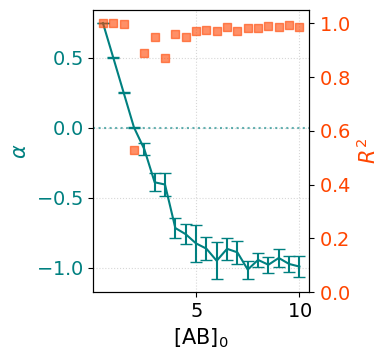

In [ ]:
results = load_streamed_pickle("barrido_ab0_to_v2.pkl")
plot_AB_barrido(results)


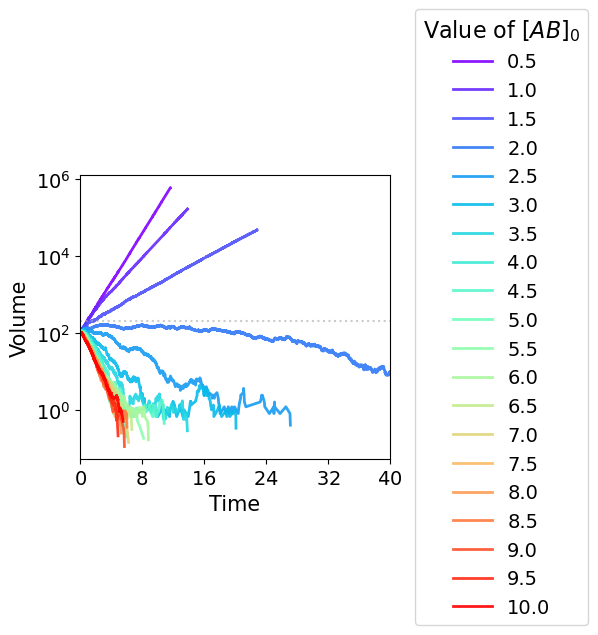

In [13]:
plot_all_volumes_AB(results, xlim= 40)

# mm

Successfully loaded 21 simulation results.
    Condition  Alpha_mean  Alpha_std   R2_mean
0         0.5    1.000794   0.002161  0.999963
1         1.0    0.999302   0.001490  0.999975
2         1.5    0.996906   0.004636  0.999964
3         2.0    0.997519   0.005239  0.999975
4         2.5    0.998008   0.002227  0.999984
5         3.0    1.001897   0.004588  0.999966
6         3.5    0.998356   0.004186  0.999961
7         4.0    1.000764   0.002900  0.999965
8         4.5    1.000597   0.004142  0.999966
9         5.0    0.999719   0.000856  0.999967
10        5.5    1.001244   0.003637  0.999968
11        6.0    0.996185   0.001211  0.999963
12        6.5    1.001596   0.004779  0.999983
13        7.0    0.997930   0.003474  0.999969
14        7.5    1.000947   0.002465  0.999976
15        8.0    0.999512   0.009481  0.999975
16        8.5    1.001821   0.006943  0.999975
17        9.0    0.998216   0.006708  0.999948
18        9.5    1.001906   0.004839  0.999964
19       10.0    

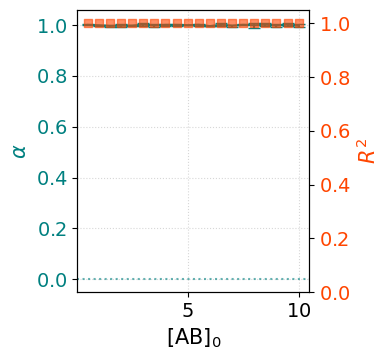

In [14]:
results = load_streamed_pickle("barrido_ab0_MM_v3.pkl")
plot_AB_barrido(results)

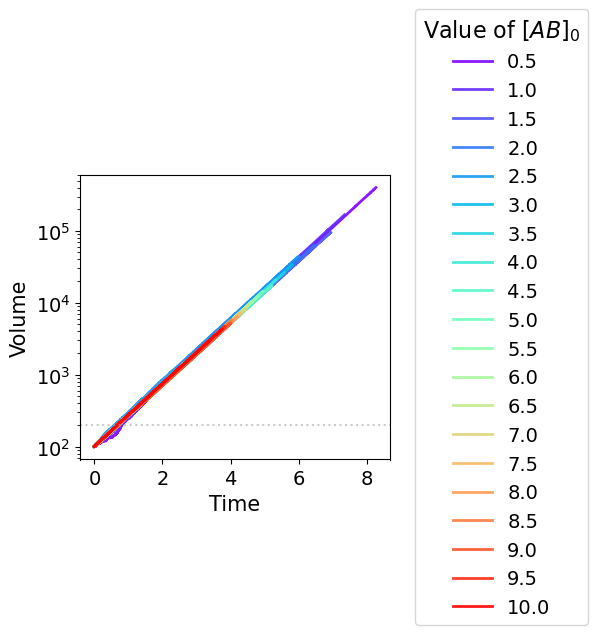

In [15]:
plot_all_volumes_AB(results,  )

# mm +

Successfully loaded 21 simulation results.
    Condition  Alpha_mean  Alpha_std   R2_mean
0         0.5    1.002112   0.001621  0.999985
1         1.0    0.999405   0.001388  0.999990
2         1.5    0.999514   0.002095  0.999990
3         2.0    1.000980   0.002470  0.999987
4         2.5    0.999835   0.000556  0.999991
5         3.0    0.997951   0.003392  0.999981
6         3.5    0.998623   0.002281  0.999986
7         4.0    0.999743   0.002580  0.999987
8         4.5    0.999506   0.001649  0.999991
9         5.0    1.001120   0.001229  0.999991
10        5.5    0.999693   0.001944  0.999991
11        6.0    1.000305   0.001632  0.999990
12        6.5    1.000603   0.002255  0.999989
13        7.0    1.000036   0.001826  0.999994
14        7.5    0.999937   0.001269  0.999992
15        8.0    0.999107   0.002771  0.999992
16        8.5    1.000379   0.001684  0.999988
17        9.0    0.999712   0.000875  0.999994
18        9.5    0.999291   0.001278  0.999994
19       10.0    

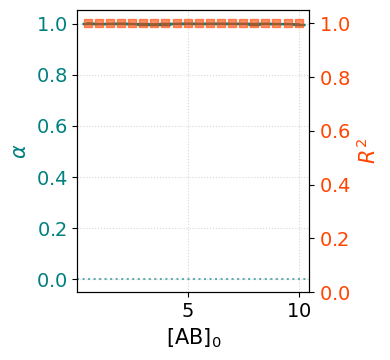

In [16]:
results = load_streamed_pickle("barrido_ab0_MM_irr.pkl")
plot_AB_barrido(results)

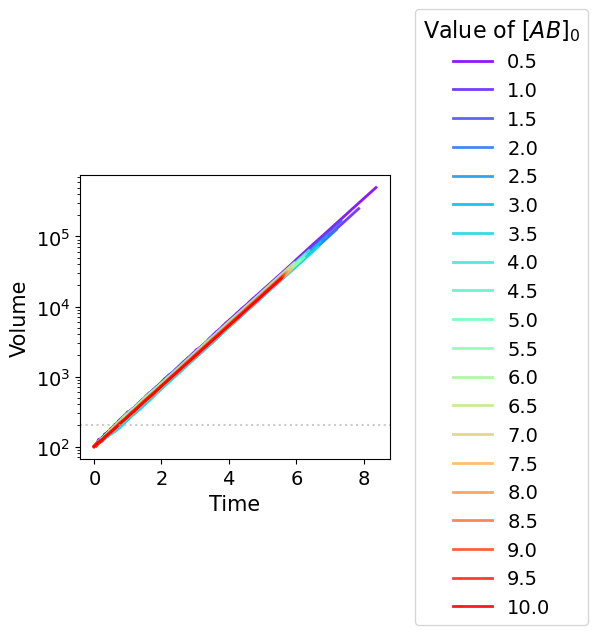

In [17]:
plot_all_volumes_AB(results,  )